#Logistic Regression

##Dataset preparation

We'll start off with a simple blob dataset

In [ ]:
from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
n_samples = 1000

# Generate linearly separable 2D data
pos, c = make_blobs(n_samples=n_samples,
                    centers=2,
                    n_features=2,
                    random_state=42)

# Create DataFrame
blobs = pd.DataFrame({"yax": pos[:, 0], "xax": pos[:, 1], "label": c})
print(blobs.head())

        yax       xax  label
0 -1.673506  7.884579      0
1  6.317580  1.419581      1
2  3.543604  0.533119      1
3  5.162714  1.399470      1
4  4.459399  5.166277      1


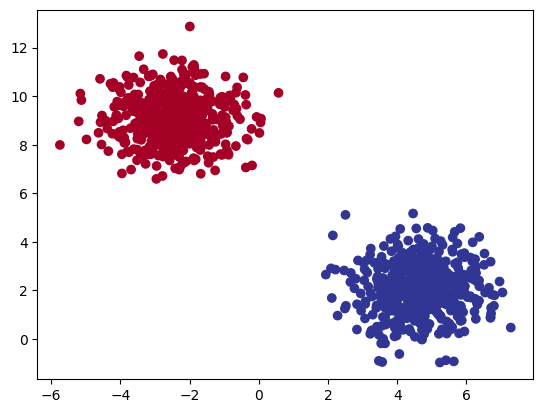

In [ ]:
# Plot the dataset
plt.scatter(pos[:, 0], pos[:, 1], c=c, cmap=plt.cm.RdYlBu)
plt.show()

our goal will be to find a line $W1x1 + W2x2 + b$ to seperate the two. we do this by optimising $W1$, $W2$ and $b$

In [ ]:
blobs

,yax,xax,label
0,-1.673506,7.884579,0
1,6.317580,1.419581,1
2,3.543604,0.533119,1
3,5.162714,1.399470,1
4,4.459399,5.166277,1
...,...,...,...
995,-1.876416,11.284979,0
996,5.364975,2.489348,1
997,3.267978,0.359608,1
998,5.765929,1.921776,1


In [ ]:
X = pos
y = c.reshape(-1, 1) # Reshapes to (1000, 1)

In [ ]:
X.shape, y.shape

((1000, 2), (1000, 1))

##Normalisation

###why?

The data isnt normalised. Its usually better to normalise it because
1. Since the inputs will be scaled to the same range, it creates a more symmetrical cost function landscape. The gradient would look really weird if one input ($x_1$) ranged from 1-5 and the other ($x_2$) ranged from 1-1000. And for a model that looks something like this: $z = w_1x_1 + w_2x_2 + b$ , a small change in $w_2$ would cause a massive change in prediction but the same change in $w_1$ would do almost nothing. after normalisation, a change in either would more or less have the same effect.

2. Logistic regression uses the sigmoid function for the final classification:\
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

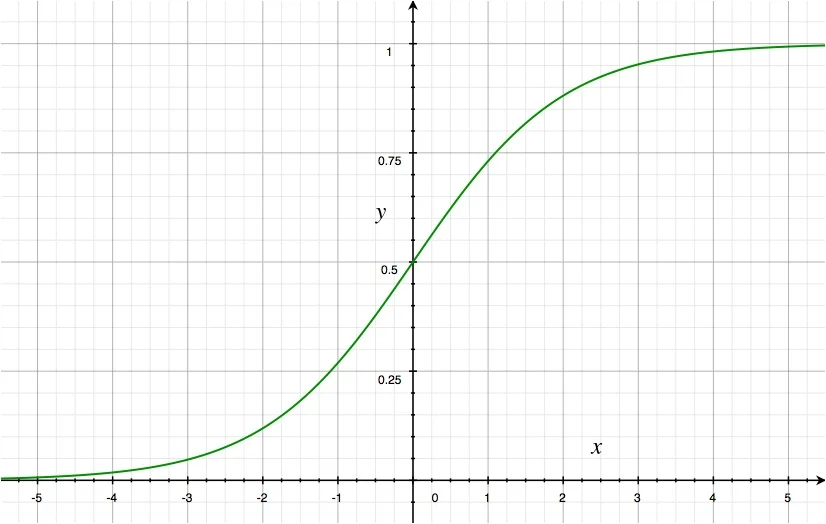

When $x$ exceeds $\pm 4$, the activation function flattens near $1$ or $0$. As a result, input values larger than $x=5$ start to lose their individuality. Normalization prevents this issue by keeping features within the responsive region of the curve.

###How should we do this?

Initially I was under the impression that itd be fine to just use min-max scaling. This isnt optimal.

If I have a bunch of values that stay in the range of 1-10 but one particlar value lies at 100 due to an error or an anomaly, since 100 is the largest value it becomes the sole decider of the degree of normalisation and can cause the other values to be squeezed and pushed far closer together just because of its own individual large deviation from the range.

Thats why rather than dumping the responsibility on just one sample, it makes more sense to distribute the weightage among all the samples by using the mean and standard deviation to get the mean to 0 and standard deviation to 1. This is done using z-score normalisation:\
$$z = \frac{x - \mu}{\sigma}$$

We subtract the mean from the samples to make the new mean 0. This does not affect the standard deviation. Once we divide the samples by the original standard deviation, the new standard deviation becomes 1.

$$ \sigma = \sqrt{\frac{\Sigma(x-\mu)^2}{N}} $$

$$ \sigma_n = \sqrt{\frac{\Sigma \left(\frac{x}{\sigma} - \frac{\mu}{\sigma}\right)^2}{N}} = \sqrt{\frac{\frac{1}{\sigma^2} \times \Sigma(x-\mu)^2}{N}} = \frac{1}{\sigma} \times \sigma = 1 $$

In [ ]:
X.shape[0]

1000

In [ ]:
split_ratio = 0.8
num_samples = X.shape[0]
split_index = int(num_samples * split_ratio)

np.random.seed(42)
shuffled_indices = np.random.permutation(num_samples)

X_shuffled = X[shuffled_indices]
y_shuffled = y[shuffled_indices]


X_train = X_shuffled[:split_index]
y_train = y_shuffled[:split_index]

X_val = X_shuffled[split_index:]
y_val = y_shuffled[split_index:]

In [ ]:
tr_mean = np.mean(X_train, axis=0)
tr_mean

array([1.12094014, 5.50990824])

In [ ]:
tr_std = np.std(X_train, axis=0)
tr_std

array([3.71987647, 3.63620234])

We use the same mean and standard deviation for validation, because it doesnt make sense to keep using different means and standard deviations for different sets of data. Especially for individual samples that we might want to run through the model. Since the model trained on data normalised on those two numbers specifically it makes sense to use those for all evaluation samples after training as well.

In [ ]:
X_train_scaled = (X_train - tr_mean) / tr_std

X_val_scaled = (X_val - tr_mean) / tr_std

X_train_scaled.shape, X_val.shape

((800, 2), (200, 2))

In [ ]:
np.mean(X_train_scaled, axis=0), np.std(X_train_scaled, axis=0)

(array([3.66373598e-17, 4.49640325e-17]), array([1., 1.]))

In [ ]:
n_features = X_train_scaled.shape[1]

W = np.zeros((n_features, 1))

b = 0.0

W, W.shape

(array([[0.],
        [0.]]),
 (2, 1))

##Binary Cross-Entropy

For calculating the loss in binary classification problems, its common to use Binary Cross-Entropy (BCE):
$$J = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{\hspace{3pt}(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{\hspace{3pt}(i)}) \right]$$

###why?

####1. Arriving at the formula naturally with the bernoulli distribution model

The Bernoulli distribution is defined by the Probability Mass Function (PMF):\
$$P(X=x) = p^x (1-p)^{1-x}$$\
where $x \in \{0, 1\}$ and $p$ is the probability of $x=1$\
so $P(X=1)$ naturally gives us $p$ and $P(X=0)$ gives us $(1-p)$

Suppose I have a coin and I want to create a dataset of all the results of my tosses. We can build a PMF taking $X=1$ as the event of getting heads, (meaning $X=0$ would be the event of getting tails) and hence $p$ as the probability of getting heads every toss (meaning $1-p$ would be the probability of getting tails).\
With an unbiased coin, $p$ would be 0.5. The probability of me having the dataset [heads, heads, heads] would be 0.5 × 0.5 × 0.5 = 0.125\
For a biased coin with an arbitrary value of $p$, such as 0.9, the probability of me having that dataset would be 0.9 × 0.9 × 0.9 = 0.729


this series of multiplications of the probabilities of each term of the dataset is given as the likelihood ($L$) of that specific set of observed data under the bernoulli model:\
$$L = \prod_{i=1}^{m} P(\text{example } i)$$

We model our logistic regression after this as well by looking at $\hat{y}^{\hspace{3pt}(i)}$ as a probability distribution. If $\hat{y}^{\hspace{3pt}(i)} = 1$ then that means the model is saying that there is a 100% chance that that the value of $y^{(i)}$ is 1. If it outputs 0.8 then that means its saying that there is an 80% chance of $y^{(i)}$ being 1 and a 20% chance of it being a 0. Now we can build a likelihood function of this as well:\
$$L = \prod_{i=1}^{m} \left[ (\hat{y}^{\hspace{3pt}(i)})^{y^{(i)}} (1-\hat{y}^{\hspace{3pt}(i)})^{(1-y^{(i)})} \right]$$

So when $y^{(i)}=1$, only $\hat{y}^{\hspace{3pt}(i)}$ is taken into account, i.e. The probability or "confidence" with which the model thinks the answer is 1.\
If $y^{(i)}=0$, $(1 - \hat{y}^{\hspace{3pt}(i)})$ is taken into account which is the probability/confidence with which the model thinks the answer is 0.

The mathematical maximum of this would be achieved in the case of a perfect model where every answer is guessed right with a 100% probability confidence by the model, giving $L=1$.

but using this directly as a form of a loss function is tricky to compute practically as the multiplication of a proper decimal for every sample would mean that $L$ would always end up being microscopically small for models with large datasets and initial low accuracies. Since we plan to use this as a loss function to minimise to 0 in the case of a perfect model, we would also prefer to have the range to be $[0,∞]$ rather than the case we have with $L$ where 1 is the output for the perfect model and the range is $[0,1]$.\
A simple way to achieve both would be to take the negative log of $L$. Once we do that and then divide it by the number of samples $m$ so as to consider the average over all the samples, we end up with the loss function that we know as Binary Cross-Entropy:\
$$- \frac{1}{m} \log(L) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{\hspace{3pt}(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{\hspace{3pt}(i)}) \right]$$

####2. Convexity

For Logistic regression models it is possible to guaruntee to have only one minimum in the Loss vs. parameters landscape. When we use BCE, the derivative of the gradient is:\
$$\frac{\partial^2 L}{\partial Z^2} = \hat{y}^{\hspace{3pt}(i)}(1 - \hat{y}^{\hspace{3pt}(i)})$$

Which is always positive since $\hat{y}^{\hspace{3pt}(i)} \in [0, 1]$


If we used something like the Mean Squared Error (MSE):\
$$L_{mse} = \frac{1}{2}(\hat{y}^{\hspace{3pt}(i)} - y)^2$$

the double derivative would end up being something far less elegant:\
$$\frac{\partial^2 L_{mse}}{\partial Z^2} = \left[ \hat{y}^{\hspace{3pt}(i)}(1 - \hat{y}^{\hspace{3pt}(i)}) + (\hat{y}^{\hspace{3pt}(i)} - y^{(i)})(1 - 2\hat{y}^{\hspace{3pt}(i)}) \right] \cdot \hat{y}^{\hspace{3pt}(i)}(1 - \hat{y}^{\hspace{3pt}(i)})$$

and more importantly, not strictly positive. meaning it wouldnt guarantee convexity.

##Sigmoid Activation

The choice of specifically using the sigmoid function for the final mapping of $Z$ to a probability distribution is not an arbitrary one like i first thought.

The bernoulli distribution function is part of the exponential family of distributions. This means that it can be reframed to the universal exponential family template:\
$$P(x) = \exp(\eta \cdot x - A)$$

the reframing looks like this:\
$$P(x) = p^x (1-p)^{1-x}$$
$$= \exp\left( \ln\left( p^x (1-p)^{1-x} \right) \right)$$
$$= \exp\left( x \ln(p) + (1-x) \ln(1-p) \right)$$

$$P(x) = \exp\left( x \ln\left(\frac{p}{1-p}\right) + \ln(1-p) \right)$$

this means for a bernoulli distribution;\
the natural parameter $(\eta) = \ln\left(\frac{p}{1-p}\right)$\
and the normalisation term $(A) = \ln(1-p)$

we can keep this aside for now.

calculating the gradient for $W$ follows this flow:\
$$\text{Gradient} = \frac{\partial L}{\partial W}= \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial W}$$
meaning the main partial derivative to worry about is $\frac{\partial L}{\partial Z}$ as $\frac{\partial Z}{\partial W}$ is relatively simple.

$$\frac{\partial L}{\partial Z} = \frac{\partial (-\log(P(x)))}{\partial Z} = \frac{\partial (-(\eta \cdot x - A))}{\partial Z}$$

We now need a function $f(Z)$ to map $Z$ to its final probability distribution form $p$. i.e. $p$ = $f(Z)$.\
Since were going to be partially differentiating $-(\eta \cdot x - A)$ wrt $Z$, it would make sense to take $\eta$ as a function $g(Z)$ of $Z$ which is fine because we already established before that $\eta$ is a function of $p$, meaning we'd also be able to find $f(z)$.

###Using a Non-Canonical linkage ($Z \neq \eta$)

taking $\eta= g(Z)$\
$$L = -(g(Z) \cdot x - A)$$
$$L = -g(Z) \cdot x + A$$
our gradient would be:
$$\frac{\partial L}{\partial Z} = -x \cdot g'(Z) + \frac{\partial A}{\partial \eta} \cdot g'(Z)$$

we know that $$\sum_{x} P(x) = 1$$

substituting the general formula:\
$$\sum_{x} \exp(\eta \cdot x - A(\eta)) = 1$$
partially differentiating both sides by $\eta$:
$$\frac{\partial}{\partial \eta} \sum_{x} \exp(\eta \cdot x - A(\eta)) = 0$$
$$\sum_{x} \left[ \exp(\eta \cdot x - A(\eta)) \cdot (x - A'(\eta)) \right] = 0$$
$$\sum_{x} \left[ P(x) \cdot (x - A'(\eta)) \right] = 0$$
$$\sum_{x} (P(x) \cdot x) - \sum_{x} (P(x) \cdot A'(\eta)) = 0$$
$$(1 \cdot P(x=1)) + (0 \cdot P(x=0)) - A'(\eta)\sum_{x} P(x) = 0$$
$$(1 \cdot p) - A'(\eta) = 0$$
$$A'(\eta)=p$$

The derivative of the normalization term wrt the natural parameter ($\frac{\partial A}{\partial \eta}$) being the probability $p$ is a universal property of the Exponential Family. going ahead with the calculation of the gradient:

$$\frac{\partial L}{\partial Z} = -x \cdot g'(Z) + p \cdot g'(Z)$$

$$\frac{\partial L}{\partial Z} = g'(Z) \cdot (p - x)$$

this means that if we use a non-canonical linkage, we get a term g'(Z) that we have to worry about. A lot of the commonly used probability distributions mappers give a complex derivative that becomes a hassle to deal with.

###Canonical linkage $(Z=\eta)$

The problem can be fixed by simply taking $\eta = g(Z) = Z$\
$g'(Z)$ becomes 1 and our gradient conveniently just becomes the difference between the model's predictions and the true label:\
$$\frac{\partial L}{\partial Z} = p - x$$
ie
$$\frac{\partial L}{\partial Z} = \hat{y}^{\hspace{3pt}(i)} - y^{(i)}$$

which we would obviously prefer over the previous non-canonical case

Now that we have established the relation between $Z$ and $\eta$, we can now find the relation/mapping of $Z$ to $p$.

$$Z = \eta = \ln\left(\frac{p}{1-p}\right)$$
$$\therefore p = \frac{1}{1 + e^{-Z}}$$
ie
$$\hat{y}^{\hspace{3pt}(i)} = \frac{1}{1 + e^{-Z}}$$

This is how we are naturally led to the sigmoid function for mapping our linear output to a probability distribution

##Gradients

gradient of $W_1$ or $W_2$:\
$$\frac{\partial L}{\partial W_{1/2}}= \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial W_{1/2}} = (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot \frac{\partial Z}{\partial W_{1/2}} = (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot \frac{\partial (W_1x_1 + W_2x_2 + b)}{\partial W_{1/2}} = (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot x_{1/2}$$

gradient of $b$:
$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial b} = (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot \frac{\partial Z}{\partial b} = (\hat{y}^{\hspace{3pt}(i)} - y^{(i)}) \cdot \frac{\partial (W_1x_1 + W_2x_2 + b)}{\partial b} = \hat{y}^{\hspace{3pt}(i)} - y^{(i)}$$

##Training

in the hypothetical case of $\hat{y}^{\hspace{3pt}(i)}$ or $(1 - \hat{y}^{\hspace{3pt}(i)})$ being 0, the loss would be infinity if the true label is 1 or 0 respectively. this could ruin the model, so we add an amount epsilon ($10^{-15}$) to ensure that the minimum possible value is not 0.

In [ ]:
epochs = 1000
lr= 0.1
epsilon= 1e-15
size= X_train_scaled.shape[0]

def sigmoid(z):
  return 1/(1+(np.exp(-z)))

for epoch in range(epochs):
  Z= X_train_scaled.dot(W) + b
  y_hat = sigmoid(Z)

  tr_bce_loss= -((y_train * np.log(y_hat + epsilon)) + ((1-y_train) * np.log(1-y_hat + epsilon))).mean()

  W_grad= (1/size) * np.dot(X_train_scaled.T, (y_hat - y_train))
  b_grad= (y_hat - y_train).mean()

  W -= lr * W_grad
  b -= lr * b_grad

  val_Z = X_val_scaled.dot(W) + b
  val_y_hat = sigmoid(val_Z)

  val_bce_loss = -((y_val * np.log(val_y_hat + epsilon)) + ((1-y_val) * np.log(1-val_y_hat + epsilon))).mean()

  if (epoch+1) % 10 == 0:
    print(f"Epoch {epoch+1} | Training BCE Loss: {tr_bce_loss:.4f} | Validation BCE Loss: {val_bce_loss:.4f}")

Epoch 10 | Training BCE Loss: 0.4072 | Validation BCE Loss: 0.3858
Epoch 20 | Training BCE Loss: 0.2668 | Validation BCE Loss: 0.2554
Epoch 30 | Training BCE Loss: 0.1957 | Validation BCE Loss: 0.1884
Epoch 40 | Training BCE Loss: 0.1538 | Validation BCE Loss: 0.1486
Epoch 50 | Training BCE Loss: 0.1266 | Validation BCE Loss: 0.1225
Epoch 60 | Training BCE Loss: 0.1075 | Validation BCE Loss: 0.1041
Epoch 70 | Training BCE Loss: 0.0935 | Validation BCE Loss: 0.0906
Epoch 80 | Training BCE Loss: 0.0827 | Validation BCE Loss: 0.0801
Epoch 90 | Training BCE Loss: 0.0742 | Validation BCE Loss: 0.0719
Epoch 100 | Training BCE Loss: 0.0673 | Validation BCE Loss: 0.0652
Epoch 110 | Training BCE Loss: 0.0617 | Validation BCE Loss: 0.0597
Epoch 120 | Training BCE Loss: 0.0569 | Validation BCE Loss: 0.0550
Epoch 130 | Training BCE Loss: 0.0528 | Validation BCE Loss: 0.0510
Epoch 140 | Training BCE Loss: 0.0493 | Validation BCE Loss: 0.0476
Epoch 150 | Training BCE Loss: 0.0462 | Validation BCE Lo

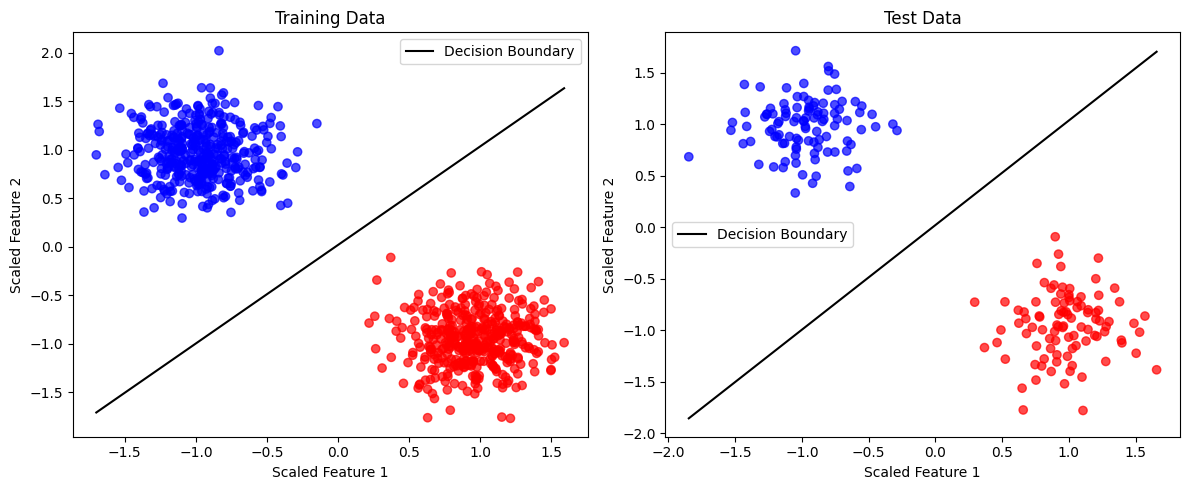

In [ ]:
w1 = W[0, 0]
w2 = W[1, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
ax1.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='bwr', alpha=0.7)

x1_min_train, x1_max_train = X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max()
x1_train_vals = np.array([x1_min_train, x1_max_train])
x2_train_vals = -(w1 * x1_train_vals + b) / w2 #Decision boundary line is where the model outputs a 50% chance i.e. Z=0

ax1.plot(x1_train_vals, x2_train_vals, color='black', label='Decision Boundary')
ax1.set_title("Training Data")
ax1.set_xlabel('Scaled Feature 1')
ax1.set_ylabel('Scaled Feature 2')
ax1.legend()


# Plot 2
ax2.scatter(X_val_scaled[:, 0], X_val_scaled[:, 1], c=y_val, cmap='bwr', alpha=0.7)

x1_min_test, x1_max_test = X_val_scaled[:, 0].min(), X_val_scaled[:, 0].max()
x1_test_vals = np.array([x1_min_test, x1_max_test])
x2_test_vals = -(w1 * x1_test_vals + b) / w2

ax2.plot(x1_test_vals, x2_test_vals, color='black', label='Decision Boundary')
ax2.set_title("Test Data")
ax2.set_xlabel('Scaled Feature 1')
ax2.set_ylabel('Scaled Feature 2')
ax2.legend()

plt.tight_layout()
plt.show()